# 01 Data Access and Masks

This notebook is the Colab entry point for the JPCZ catalog project. It clones the GitHub repository into the Colab runtime, installs the project, and loads the initial spatial definitions for the working domain, JPCZ polygon, and vorticity box.

Before running the setup cell below, replace the placeholder `REPO_URL` with your actual GitHub repository URL.

In [1]:
REPO_URL = "https://github.com/angelicasophyaramirez-blip/JPCZcatalogcolab.git"
BRANCH = "main"
REPO_DIR = "/content/JPCZcatalog"

if "<your-username>" in REPO_URL or "<your-repo>" in REPO_URL:
    raise ValueError("Replace REPO_URL with your actual GitHub repository URL before running this notebook.")


In [2]:
import os
import shutil
import subprocess
import sys

if os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)

subprocess.run([
    "git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, REPO_DIR
], check=True)
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q", "-r", f"{REPO_DIR}/requirements-colab.txt"
], check=True)
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q", "-e", REPO_DIR
], check=True)

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")


Working directory: /content/JPCZcatalog


In [3]:
import sys
import os

# Add the repository directory to sys.path to ensure the module can be found
REPO_DIR = '/content/JPCZcatalog'
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

from jpcz_catalog.config import (
    EVENT_FIELD_UNITS,
    EXTENDED_DOMAIN,
    JPCZ_POLYGON_VERTICES,
    VORTICITY_BOX,
    WORKING_DOMAIN,
)

print("Working domain:", WORKING_DOMAIN)
print("Extended domain:", EXTENDED_DOMAIN)
print("Vorticity box:", VORTICITY_BOX)
print("JPCZ polygon vertices:", JPCZ_POLYGON_VERTICES)
print("Field units:", EVENT_FIELD_UNITS)


Working domain: BoundingBox(lon_min=120.0, lon_max=150.0, lat_min=30.0, lat_max=50.0)
Extended domain: BoundingBox(lon_min=120.0, lon_max=160.0, lat_min=30.0, lat_max=50.0)
Vorticity box: BoundingBox(lon_min=127.0, lon_max=140.0, lat_min=37.0, lat_max=45.5)
JPCZ polygon vertices: ((129.5, 41.0), (136.0, 37.4), (134.5, 35.8), (128.8, 38.0))
Field units: {'divergence_925hpa': 's^-1', 'divergence_925hpa_display': '1e-5 s^-1', 'relative_vorticity_925hpa': 's^-1', 'relative_vorticity_925hpa_display': '1e-5 s^-1', 'seoul_minus_sapporo_slp': 'hPa'}


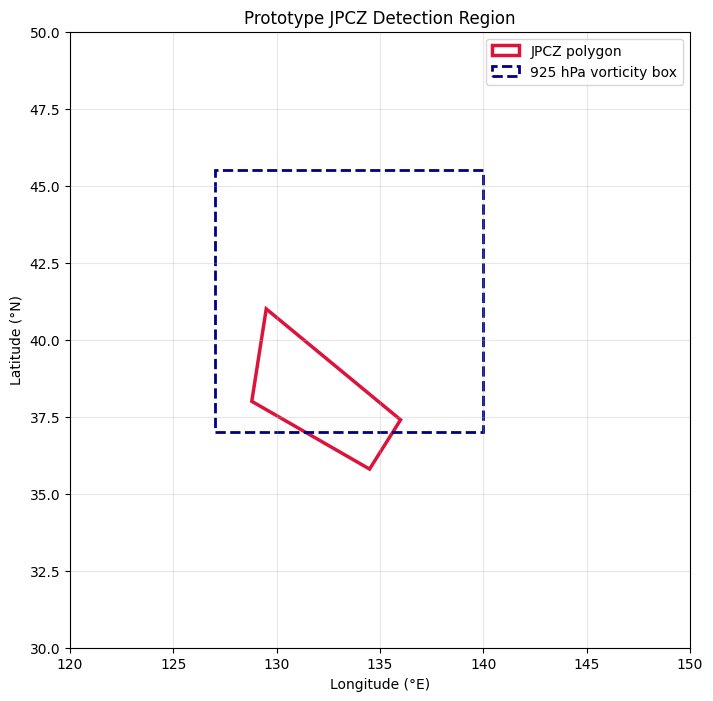

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle

from jpcz_catalog.config import (
    JPCZ_POLYGON_VERTICES,
    VORTICITY_BOX,
    WORKING_DOMAIN,
)

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_xlim(WORKING_DOMAIN.lon_min, WORKING_DOMAIN.lon_max)
ax.set_ylim(WORKING_DOMAIN.lat_min, WORKING_DOMAIN.lat_max)

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("Prototype JPCZ Detection Region")

polygon = Polygon(
    JPCZ_POLYGON_VERTICES,
    closed=True,
    fill=False,
    edgecolor="crimson",
    linewidth=2.5,
    label="JPCZ polygon",
)

vort_box = Rectangle(
    (VORTICITY_BOX.lon_min, VORTICITY_BOX.lat_min),
    VORTICITY_BOX.lon_max - VORTICITY_BOX.lon_min,
    VORTICITY_BOX.lat_max - VORTICITY_BOX.lat_min,
    fill=False,
    edgecolor="navy",
    linestyle="--",
    linewidth=2,
    label="925 hPa vorticity box",
)

ax.add_patch(polygon)
ax.add_patch(vort_box)

ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.show()


In [5]:
%pip install -q cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 55.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


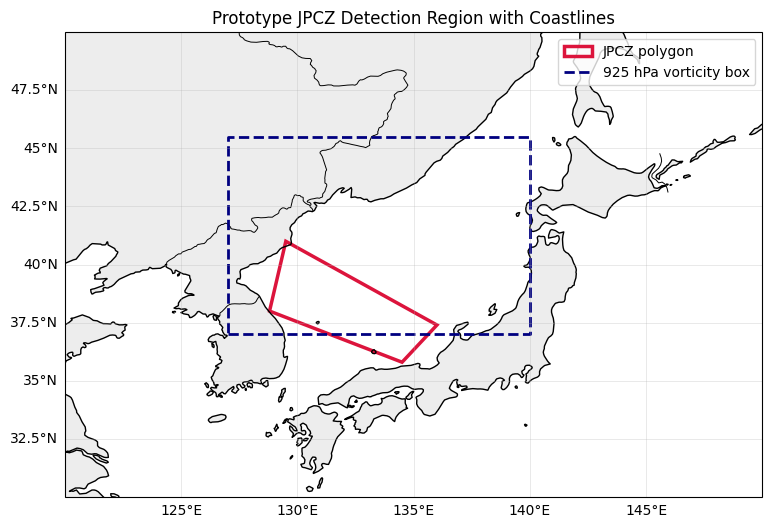

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from jpcz_catalog.config import (
    JPCZ_POLYGON_VERTICES,
    VORTICITY_BOX,
    WORKING_DOMAIN,
)

fig = plt.figure(figsize=(9, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(
    [
        WORKING_DOMAIN.lon_min,
        WORKING_DOMAIN.lon_max,
        WORKING_DOMAIN.lat_min,
        WORKING_DOMAIN.lat_max,
    ],
    crs=ccrs.PlateCarree(),
)

ax.coastlines(resolution="50m", linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.7)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.4)
ax.add_feature(cfeature.OCEAN, facecolor="white", alpha=1.0)

polygon = Polygon(
    JPCZ_POLYGON_VERTICES,
    closed=True,
    fill=False,
    edgecolor="crimson",
    linewidth=2.5,
    transform=ccrs.PlateCarree(),
    label="JPCZ polygon",
)
ax.add_patch(polygon)

rect_lon = [
    VORTICITY_BOX.lon_min,
    VORTICITY_BOX.lon_max,
    VORTICITY_BOX.lon_max,
    VORTICITY_BOX.lon_min,
    VORTICITY_BOX.lon_min,
]
rect_lat = [
    VORTICITY_BOX.lat_min,
    VORTICITY_BOX.lat_min,
    VORTICITY_BOX.lat_max,
    VORTICITY_BOX.lat_max,
    VORTICITY_BOX.lat_min,
]
ax.plot(
    rect_lon,
    rect_lat,
    linestyle="--",
    color="navy",
    linewidth=2,
    transform=ccrs.PlateCarree(),
    label="925 hPa vorticity box",
)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.set_title("Prototype JPCZ Detection Region with Coastlines")
ax.legend(loc="upper right")
plt.show()


In [7]:
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr


In [8]:
import xarray as xr

from jpcz_catalog.config import WORKING_DOMAIN

STORE = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"

ds = xr.open_zarr(
    STORE,
    chunks=None,
    storage_options={"token": "anon"},
)

print("valid_time_start:", ds.attrs.get("valid_time_start"))
print("valid_time_stop:", ds.attrs.get("valid_time_stop"))
print("sample variables:", list(ds.data_vars)[:15])

era5_test = ds[
    [
        "u_component_of_wind",
        "v_component_of_wind",
        "mean_sea_level_pressure",
    ]
].sel(
    time=slice("2018-02-02", "2018-02-07T23:00:00"),
    level=925,
    longitude=slice(WORKING_DOMAIN.lon_min, WORKING_DOMAIN.lon_max),
    latitude=slice(WORKING_DOMAIN.lat_max, WORKING_DOMAIN.lat_min),
)

print(era5_test)


valid_time_start: 1940-01-01
valid_time_stop: 2025-12-31
sample variables: ['100m_u_component_of_wind', '100m_v_component_of_wind', '10m_u_component_of_neutral_wind', '10m_u_component_of_wind', '10m_v_component_of_neutral_wind', '10m_v_component_of_wind', '10m_wind_gust_since_previous_post_processing', '2m_dewpoint_temperature', '2m_temperature', 'air_density_over_the_oceans', 'angle_of_sub_gridscale_orography', 'anisotropy_of_sub_gridscale_orography', 'benjamin_feir_index', 'boundary_layer_dissipation', 'boundary_layer_height']
<xarray.Dataset> Size: 17MB
Dimensions:                  (time: 144, latitude: 81, longitude: 121)
Coordinates:
  * time                     (time) datetime64[ns] 1kB 2018-02-02 ... 2018-02...
  * latitude                 (latitude) float32 324B 50.0 49.75 ... 30.25 30.0
  * longitude                (longitude) float32 484B 120.0 120.2 ... 150.0
    level                    int64 8B 925
Data variables:
    u_component_of_wind      (time, latitude, longitude) fl

In [9]:
era5_sample = era5_test.isel(time=slice(0, 2)).load()

print(era5_sample)
print("u units:", era5_sample["u_component_of_wind"].attrs.get("units"))
print("v units:", era5_sample["v_component_of_wind"].attrs.get("units"))
print("msl units:", era5_sample["mean_sea_level_pressure"].attrs.get("units"))


<xarray.Dataset> Size: 236kB
Dimensions:                  (time: 2, latitude: 81, longitude: 121)
Coordinates:
  * time                     (time) datetime64[ns] 16B 2018-02-02 2018-02-02T...
  * latitude                 (latitude) float32 324B 50.0 49.75 ... 30.25 30.0
  * longitude                (longitude) float32 484B 120.0 120.2 ... 150.0
    level                    int64 8B 925
Data variables:
    u_component_of_wind      (time, latitude, longitude) float32 78kB 0.1442 ...
    v_component_of_wind      (time, latitude, longitude) float32 78kB -3.216 ...
    mean_sea_level_pressure  (time, latitude, longitude) float32 78kB 1.04e+0...
Attributes:
    last_updated:           2026-04-16 02:46:16.250177+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-12-31
    valid_time_stop_era5t:  2026-04-10
u units: m s**-1
v units: m s**-1
msl units: Pa
